# DAML Homework 2 — Night Chorus
## One dataset, three ways to draw a decision boundary

**Mandatory core: 30–45 minutes · Optional deep dive: 45–90+ minutes · 100 points + 10 bonus**

A fictional field sensor has summarized short nighttime audio clips using two normalized acoustic features. Your job is to classify each clip as an **insect chirp (`0`)** or a **frog call (`1`)**.

The dataset is synthetic and intentionally shaped to reveal a central idea: different supervised-learning algorithms make different assumptions about what a useful decision boundary should look like.

<div style="border-left: 5px solid #2f855a; padding: 0.8em 1em; background: #f0fff4;">
<b>Learning objectives</b><br>
By the end, you should be able to:
<ol>
  <li>keep training, validation, and test data in distinct roles;</li>
  <li>implement and tune a binary K-nearest-neighbors classifier;</li>
  <li>turn logistic-regression scores into probabilities and labels;</li>
  <li>compute Gini impurity and understand how a tree chooses splits;</li>
  <li>select a model with validation data and evaluate it once on test data.</li>
</ol>
</div>

<div style="border-left: 5px solid #3182ce; padding: 0.8em 1em; background: #ebf8ff;">
<b>How this homework is scaffolded</b><br><br>
Every required algorithm begins with a worked micro-example and a short recipe. The training loops for logistic regression and the decision tree are provided. Most required TODOs are one to three lines, and every graded function has an immediate public check.<br><br>
This builds on last week's <code>prediction → objective → fitted model</code> workflow, but shifts the focus from continuous prediction to binary classification and model selection.
</div>

## Working policy: make a real attempt first

AI tools may be used **as a tutor when you are stuck**, after you have made a fair initial attempt. Good uses include asking for a hint, requesting an explanation of an error, or checking your reasoning. You remain responsible for understanding every submitted line and for reproducing the ideas independently on the cumulative end-of-semester assessment.

Conceptual discussion with classmates is encouraged. Do not exchange completed code or submit work you cannot explain. Briefly disclose substantial assistance at the end.

## Submission contract

- Complete only cells marked **YOUR CODE** or **YOUR RESPONSE**.
- Keep every required function name and signature unchanged.
- Use only NumPy and Matplotlib in the mandatory section.
- Do not call scikit-learn or another ready-made classifier inside a required function.
- Public checks are small; hidden checks use new values and shapes.
- Before submitting: **Restart kernel/runtime → Run all**.

The optional runway notebook is not submitted. Submit only this completed notebook.

In [7]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

## Mission setup

Each row has two comparable-scale features:

1. `frequency_pattern` — a normalized summary of dominant frequencies;
2. `pulse_regularity` — a normalized summary of temporal spacing.

Labels are `0 = insect` and `1 = frog`. The data are synthetic, deterministic, and generated locally; nothing is downloaded.

In [13]:
def make_night_chorus(n_samples=180, noise=0.16, seed=100):
    """Generate two noisy rings so model assumptions are easy to see."""
    rng = np.random.default_rng(seed)
    n_insect = n_samples // 2
    n_frog = n_samples - n_insect

    insect_angle = rng.uniform(0.0, 2.0 * np.pi, n_insect)
    frog_angle = rng.uniform(0.0, 2.0 * np.pi, n_frog)

    insect = np.column_stack([np.cos(insect_angle), np.sin(insect_angle)])
    frog = 0.48 * np.column_stack([np.cos(frog_angle), np.sin(frog_angle)])

    X = np.vstack([insect, frog])
    X += rng.normal(scale=noise, size=X.shape)
    X = 3.5 + 1.25 * X  # place both features on an interpretable 1–6-ish scale
    y = np.concatenate([
        np.zeros(n_insect, dtype=int),
        np.ones(n_frog, dtype=int),
    ])
    return X, y


def stratified_split_indices(y, train_fraction=0.60, val_fraction=0.20, seed=30):
    """Return disjoint class-balanced train/validation/test index arrays."""
    rng = np.random.default_rng(seed)
    split_pieces = {"train": [], "val": [], "test": []}

    for label in np.unique(y):
        label_indices = np.flatnonzero(y == label)
        rng.shuffle(label_indices)
        n = len(label_indices)
        n_train = int(train_fraction * n)
        n_val = int(val_fraction * n)

        split_pieces["train"].append(label_indices[:n_train])
        split_pieces["val"].append(label_indices[n_train:n_train + n_val])
        split_pieces["test"].append(label_indices[n_train + n_val:])

    result = {}
    for name, pieces in split_pieces.items():
        result[name] = np.concatenate(pieces)
        rng.shuffle(result[name])
    return result["train"], result["val"], result["test"]


X_all, y_all = make_night_chorus()
train_idx, val_idx, test_idx = stratified_split_indices(y_all)

X_train, y_train = X_all[train_idx], y_all[train_idx]
X_val, y_val = X_all[val_idx], y_all[val_idx]
X_test, y_test = X_all[test_idx], y_all[test_idx]

feature_names = ["frequency pattern", "pulse regularity"]
class_names = {0: "insect", 1: "frog"}

In [15]:
y_all

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1])

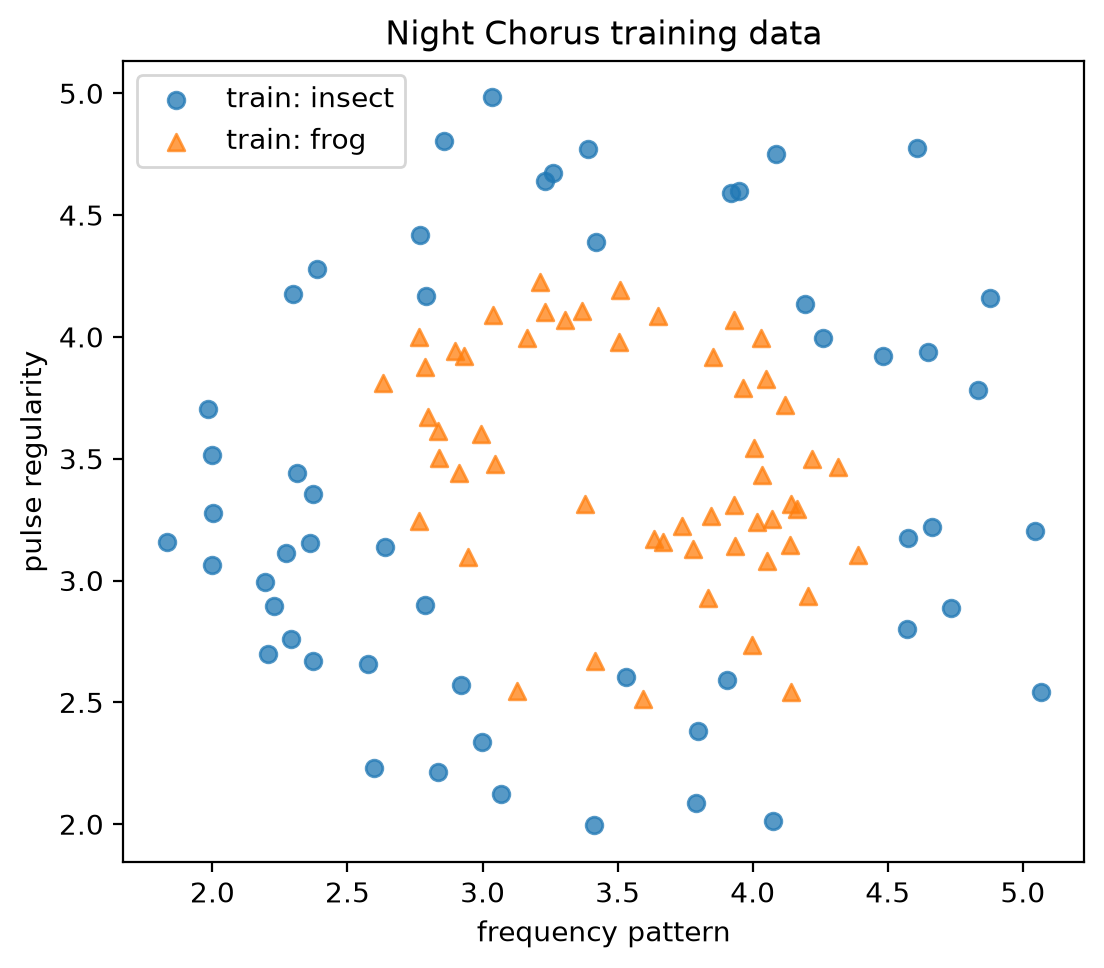

In [9]:
plt.figure(figsize=(6.2, 5.2))
for label, marker in [(0, "o"), (1, "^")]:
    mask = y_train == label
    plt.scatter(
        X_train[mask, 0], X_train[mask, 1],
        marker=marker, alpha=0.75, label=f"train: {class_names[label]}"
    )
plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.title("Night Chorus training data")
plt.legend()
plt.show()

### Split checkpoint — ungraded

| Split | Used for | Never use it for |
|---|---|---|
| Train | fitting/storing the model | final performance claims |
| Validation | choosing `k`, depth, or model family | fitting the final report repeatedly |
| Test | one final report after choices are frozen | tuning |

In [17]:
print("Train:", X_train.shape, np.bincount(y_train))
print("Validation:", X_val.shape, np.bincount(y_val))
print("Test:", X_test.shape, np.bincount(y_test))

assert len(set(train_idx) & set(val_idx)) == 0
assert len(set(train_idx) & set(test_idx)) == 0
assert len(set(val_idx) & set(test_idx)) == 0
print("✓ The three splits are disjoint")

Train: (108, 2) [54 54]
Validation: (36, 2) [18 18]
Test: (36, 2) [18 18]
✓ The three splits are disjoint


## Part 1 — Evaluation before algorithms (8 points, ~4 minutes)

Accuracy is the fraction of labels predicted correctly:

$$
\mathrm{accuracy}=\frac{1}{n}\sum_{i=1}^n \mathbf{1}(\hat y_i=y_i).
$$

**Recipe**

1. Compare `y_true == y_pred` to obtain Booleans.
2. Take their mean.
3. Convert the result to `float`.

In [28]:
def accuracy_score(y_true, y_pred):
    """Return the fraction of matching labels as a Python float."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    if y_true.shape != y_pred.shape:
        raise ValueError("y_true and y_pred must have the same shape")
    if y_true.size == 0:
        raise ValueError("accuracy is undefined for empty inputs")

    # TODO: compare the arrays, then average the Boolean result.
    return np.mean(y_true == y_pred)

In [29]:
y_tiny = np.array([0, 1, 1, 0])
pred_tiny = np.array([0, 1, 0, 0])
assert np.isclose(accuracy_score(y_tiny, pred_tiny), 0.75)
print("✓ Public check passed")

✓ Public check passed


In [30]:
majority_label = int(np.mean(y_train) >= 0.5)
baseline_predictions = np.full(y_val.shape, majority_label, dtype=int)
print("Majority-class validation accuracy:", accuracy_score(y_val, baseline_predictions))

Majority-class validation accuracy: 0.5


## Part 2 — K-nearest neighbors: local votes (37 points, ~11 minutes)

KNN classifies a new row using nearby training labels. It stores the training set rather than fitting a global line.

### Worked micro-example

For one query `q`, Euclidean distance to training row `x_i` is

$$
d(x_i,q)=\sqrt{\sum_{j=1}^d(x_{ij}-q_j)^2}.
$$

In an `(n, d)` matrix, sum over `axis=1` because each **row** should collapse to one distance.

In [31]:
X_demo = np.array([[0.0, 0.0], [1.0, 0.0], [0.0, 2.0]])
query_demo = np.array([0.9, 0.1])

demo_differences = X_demo - query_demo
demo_distances = np.sqrt(np.sum(demo_differences**2, axis=1))
print("Differences:\n", demo_differences)
print("One distance per row:", demo_distances)

Differences:
 [[-0.9 -0.1]
 [ 0.1 -0.1]
 [-0.9  1.9]]
One distance per row: [0.9055 0.1414 2.1024]


### 2A. Distances (12 points)

**YOUR CODE:** The subtraction and squaring are already written. Complete the reduction and square root.

In [ ]:
def euclidean_distances(X_train, query):
    """Return the Euclidean distance from query to every row of X_train."""
    X_train = np.asarray(X_train, dtype=float)
    query = np.asarray(query, dtype=float)

    # These two steps are provided so the only decision is the reduction axis.
    differences = X_train - query
    squared_differences = differences ** 2

    return np.sqrt(np.sum(squared_differences, axis = 1))

In [33]:
expected = np.array([np.sqrt(0.82), np.sqrt(0.02), np.sqrt(4.42)])
actual = euclidean_distances(X_demo, query_demo)
assert actual.shape == (3,)
assert np.allclose(actual, expected)
print("✓ Public check passed")

✓ Public check passed


### 2B. Neighbors and majority vote (18 points)

**Recipe**

1. Compute distances.
2. `np.argsort(distances)` gives row indices from nearest to farthest.
3. Keep the first `k` indices.
4. Average their binary labels; predict `1` when the mean is at least `0.5`.

Steps 1–3 are already in the starter code. Your TODO is the vote.

In [ ]:
def knn_predict_one(X_train, y_train, query, k):
    """Predict one binary label by majority vote among the k nearest rows."""
    X_train = np.asarray(X_train, dtype=float)
    y_train = np.asarray(y_train, dtype=int)
    if not isinstance(k, (int, np.integer)) or not 1 <= k <= len(X_train):
        raise ValueError("k must be an integer from 1 through len(X_train)")

    # Distance, sort, slice: the neighbor search is already written for you.
    distances = euclidean_distances(X_train, query)
    neighbor_indices = np.argsort(distances)[:k]
    neighbor_labels = y_train[neighbor_indices]

    return 1 if np.mean(neighbor_labels) >= 0.5 else 0

In [35]:
X_tiny = np.array([[0.0, 0.0], [1.0, 0.0], [0.0, 2.0], [3.0, 3.0]])
y_tiny = np.array([0, 0, 1, 1])
assert knn_predict_one(X_tiny, y_tiny, np.array([0.9, 0.1]), k=3) == 0
assert knn_predict_one(X_tiny, y_tiny, np.array([2.8, 2.9]), k=1) == 1
print("✓ Public check passed")

✓ Public check passed


In [36]:
def knn_predict(X_train, y_train, X_query, k):
    """Provided wrapper: call your one-example function for every query row."""
    return np.array([
        knn_predict_one(X_train, y_train, query, k)
        for query in np.asarray(X_query)
    ], dtype=int)

### 2C. Tune `k` on validation data (7 points)

Small `k` is flexible and can chase noise. Large `k` is smoother and can wash away useful local structure. We therefore compare candidate values on the **validation** split.

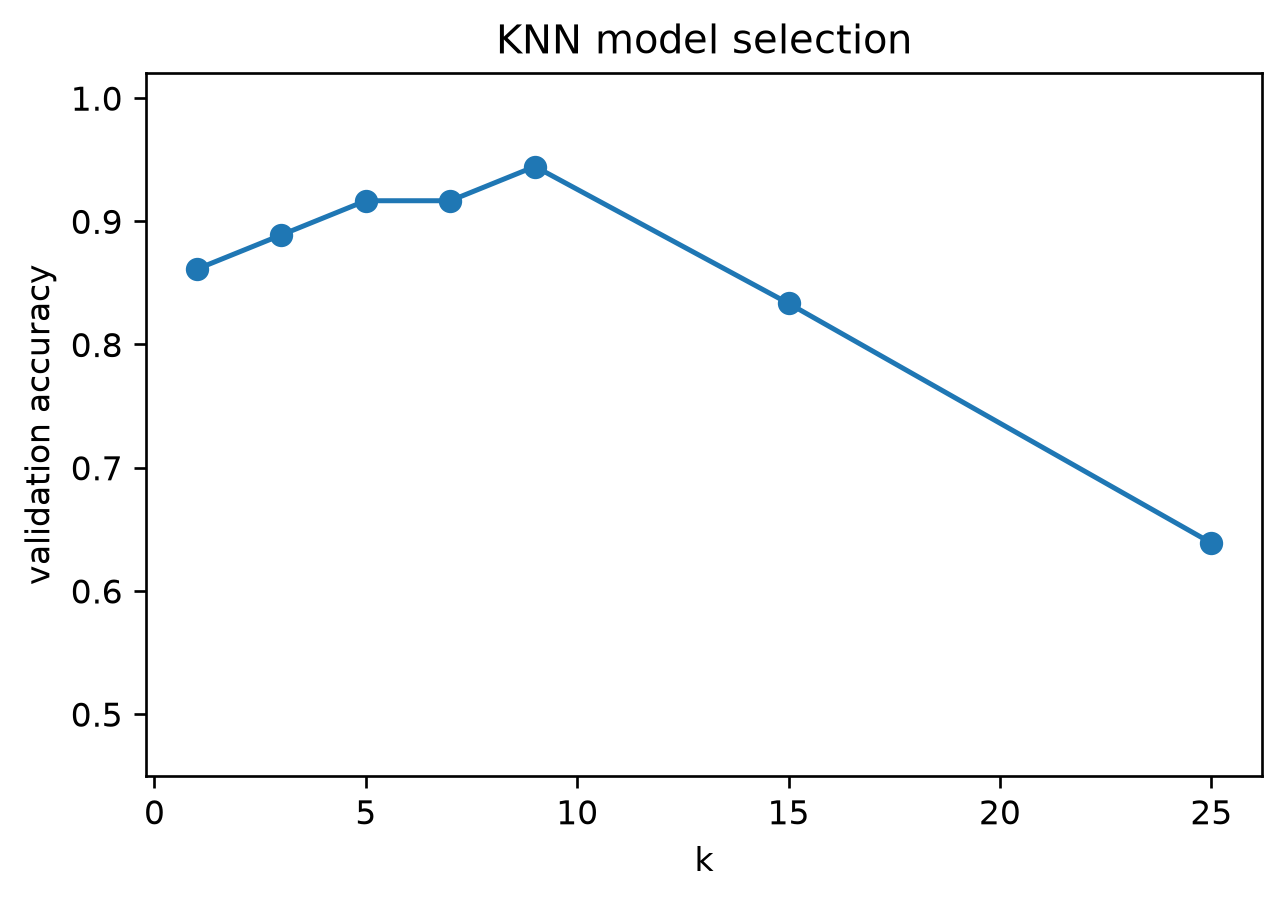

k= 1: 0.861
k= 3: 0.889
k= 5: 0.917
k= 7: 0.917
k= 9: 0.944
k=15: 0.833
k=25: 0.639


In [37]:
candidate_ks = np.array([1, 3, 5, 7, 9, 15, 25])
knn_val_scores = np.array([
    accuracy_score(y_val, knn_predict(X_train, y_train, X_val, int(k)))
    for k in candidate_ks
])

plt.figure(figsize=(6.0, 3.8))
plt.plot(candidate_ks, knn_val_scores, marker="o")
plt.xlabel("k")
plt.ylabel("validation accuracy")
plt.ylim(0.45, 1.02)
plt.title("KNN model selection")
plt.show()

for k, score in zip(candidate_ks, knn_val_scores):
    print(f"k={k:>2}: {score:.3f}")

In [55]:
def select_best_k(k_values, validation_scores):
    """Return the smallest k tied for the highest validation score."""
    k_values = np.asarray(k_values, dtype=int)
    validation_scores = np.asarray(validation_scores, dtype=float)
    if k_values.shape != validation_scores.shape or k_values.size == 0:
        raise ValueError("k_values and validation_scores must be nonempty and aligned")

    best_score = np.max(validation_scores)

    # TODO 1: keep the k values whose score equals best_score.
    indices_of_best_k = validation_scores == best_score
    best_k = k_values[indices_of_best_k]

    # TODO 2: return the smallest tied k as an int.
    return min(best_k)
    
    raise NotImplementedError("Complete select_best_k")

In [56]:
assert select_best_k([1, 3, 5], [0.8, 0.9, 0.9]) == 3
assert select_best_k([9, 1, 5], [0.7, 0.8, 0.6]) == 1
print("✓ Public check passed")

✓ Public check passed


In [57]:
best_k = select_best_k(candidate_ks, knn_val_scores)
knn_val_predictions = knn_predict(X_train, y_train, X_val, best_k)
knn_val_accuracy = accuracy_score(y_val, knn_val_predictions)
print(f"Selected k={best_k}; validation accuracy={knn_val_accuracy:.3f}")

Selected k=9; validation accuracy=0.944


## Part 3 — Logistic regression: one global probability boundary (28 points, ~8 minutes)

Logistic regression computes

$$
z=Xw+b, \qquad p(y=1\mid x)=\sigma(z)=\frac{1}{1+e^{-z}}.
$$

A threshold converts probabilities to labels. Unlike KNN, ordinary two-feature logistic regression draws one straight decision boundary.

**This week you are implementing the forward path, not another optimizer.** The annotated training loop is provided after the three small functions.

In [58]:
demo_scores = np.array([-2.0, 0.0, 2.0])
print("Expected sigmoid pattern: small, 0.5, large")
print("Reference values:", 1 / (1 + np.exp(-demo_scores)))

Expected sigmoid pattern: small, 0.5, large
Reference values: [0.1192 0.5    0.8808]


### 3A. Sigmoid (10 points)

The clipping line is supplied for numerical stability. Complete the formula itself.

In [59]:
def sigmoid(z):
    """Apply the sigmoid elementwise to a scalar or NumPy array."""
    z = np.asarray(z, dtype=float)

    # Clipping prevents exp(...) from overflowing on very large scores.
    z = np.clip(z, -500.0, 500.0)

    return 1 / (1 + np.exp(-z))

    # TODO: translate sigma(z) = 1 / (1 + exp(-z)) into NumPy.
    raise NotImplementedError("Complete sigmoid")

In [60]:
assert np.allclose(sigmoid(np.array([-2.0, 0.0, 2.0])),
                   np.array([0.11920292, 0.5, 0.88079708]))
assert np.isfinite(sigmoid(np.array([-1000.0, 1000.0]))).all()
print("✓ Public check passed")

✓ Public check passed


### 3B. Probability prediction (10 points)

Compute one score per row, then apply your sigmoid. The score line is supplied.

In [61]:
def logistic_predict_proba(X, w, b):
    """Return P(y=1 | x) for each row of X."""
    X = np.asarray(X, dtype=float)
    w = np.asarray(w, dtype=float)

    # Step 1 is provided: one linear score per row.
    scores = X @ w + b

    # TODO: turn the scores into probabilities.
    return sigmoid(scores)
    raise NotImplementedError("Complete logistic_predict_proba")

In [62]:
X_tiny = np.array([[1.0, 0.0], [0.0, 1.0], [1.0, 1.0]])
w_tiny = np.array([2.0, -1.0])
b_tiny = -0.5
expected = sigmoid(X_tiny @ w_tiny + b_tiny)
assert np.allclose(logistic_predict_proba(X_tiny, w_tiny, b_tiny), expected)
print("✓ Public check passed")

✓ Public check passed


### 3C. Probability → label (8 points)

Compare probabilities to the threshold and convert the Boolean array to integers.

In [82]:
def logistic_predict(X, w, b, threshold=0.5):
    """Convert logistic probabilities into 0/1 predictions."""
    if not 0.0 < threshold < 1.0:
        raise ValueError("threshold must lie strictly between 0 and 1")

    probabilities = logistic_predict_proba(X, w, b)

    # TODO: threshold the probabilities and return an integer array.

    return np.astype(probabilities >= 0.5, int)
    raise NotImplementedError("Complete logistic_predict")

In [83]:
assert np.array_equal(
    logistic_predict(X_tiny, w_tiny, b_tiny, threshold=0.5),
    (expected >= 0.5).astype(int),
)
print("✓ Public check passed")

✓ Public check passed


In [72]:
def fit_logistic_guided(X, y, learning_rate=0.05, num_steps=2000, l2=0.01):
    """Provided batch-gradient trainer for binary logistic regression."""
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    n, d = X.shape
    w = np.zeros(d)
    b = 0.0
    history = []

    for _ in range(num_steps):
        # Forward pass: scores -> probabilities.
        probabilities = sigmoid(X @ w + b)
        safe_p = np.clip(probabilities, 1e-12, 1.0 - 1e-12)

        # Binary negative log-likelihood plus a small L2 penalty on w.
        loss = -np.mean(y * np.log(safe_p) + (1.0 - y) * np.log(1.0 - safe_p))
        loss += 0.5 * l2 * np.sum(w**2)
        history.append(loss)

        # Gradient and parameter update. You saw this pattern last week.
        error = probabilities - y
        grad_w = X.T @ error / n + l2 * w
        grad_b = np.mean(error)
        w -= learning_rate * grad_w
        b -= learning_rate * grad_b

    return w, float(b), np.asarray(history)

Learned w: [0.3786 0.0837]
Learned b: -1.5746617821121611
Logistic validation accuracy: 0.667


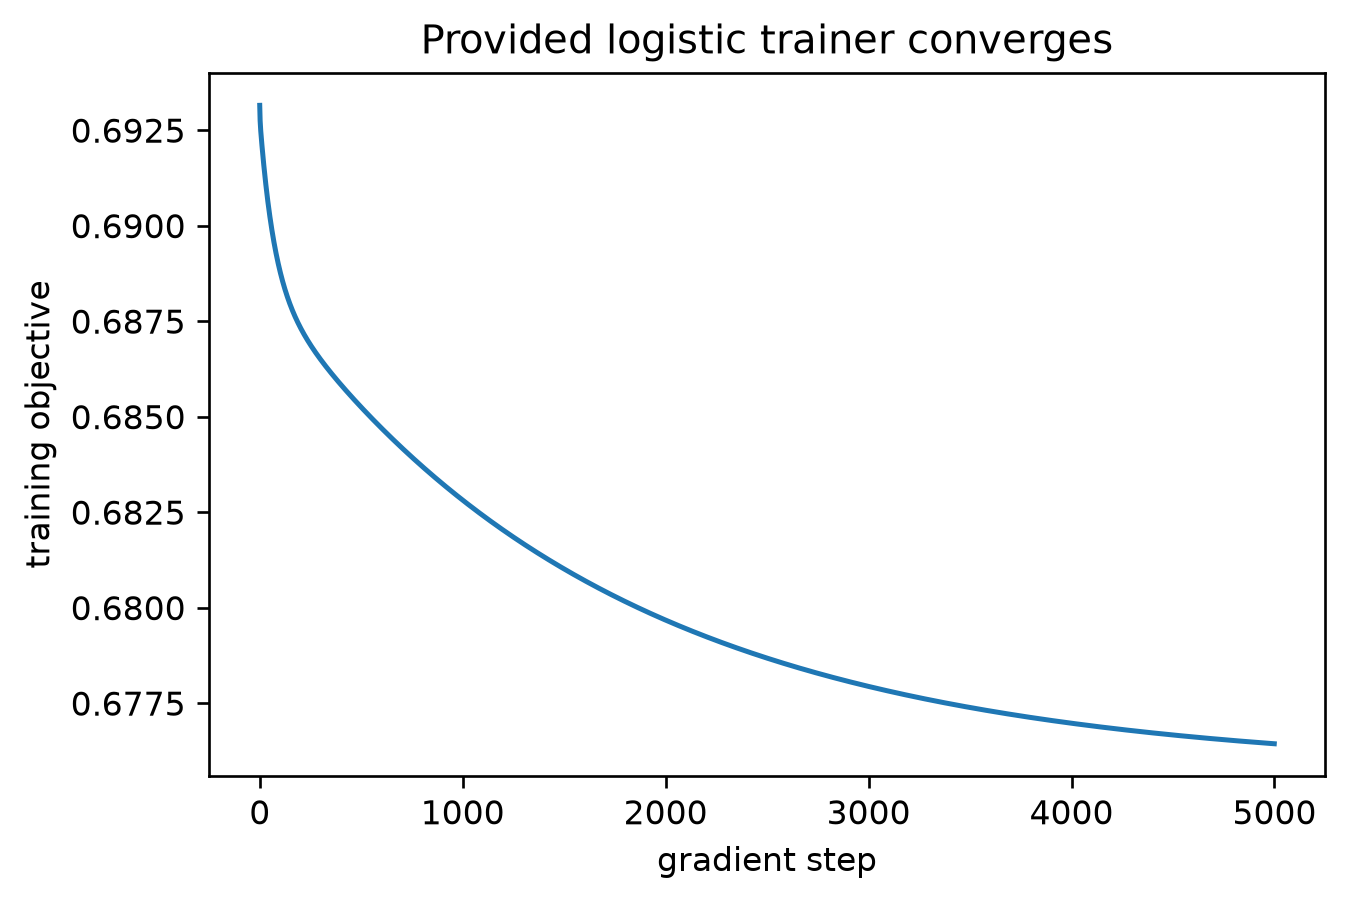

In [74]:
logistic_w, logistic_b, logistic_history = fit_logistic_guided(X_train, y_train, num_steps = 5000)
logistic_val_predictions = logistic_predict(X_val, logistic_w, logistic_b)
logistic_val_accuracy = accuracy_score(y_val, logistic_val_predictions)

print("Learned w:", logistic_w)
print("Learned b:", logistic_b)
print(f"Logistic validation accuracy: {logistic_val_accuracy:.3f}")

plt.figure(figsize=(6.0, 3.8))
plt.plot(logistic_history)
plt.xlabel("gradient step")
plt.ylabel("training objective")
plt.title("Provided logistic trainer converges")
plt.show()

## Part 4 — Decision trees: split toward purity (22 points, ~8 minutes)

For binary labels,

$$
G(y)=1-p_0^2-p_1^2.
$$

- A pure node has Gini impurity `0`.
- A balanced binary node has Gini impurity `0.5`.
- A candidate split is scored by the sample-count-weighted impurity of its two children.

The recursive tree-building code is provided. You implement only the two quantities it needs to compare splits.

### 4A. Gini impurity (12 points)

The class proportions are supplied. Complete one formula.

In [84]:
def gini_impurity(y):
    """Return binary Gini impurity. By convention, an empty node returns 0."""
    y = np.asarray(y, dtype=int)
    if y.size == 0:
        return 0.0

    # The class proportions are provided.
    p1 = np.mean(y == 1)
    p0 = 1.0 - p1

    # TODO: implement G = 1 - p0^2 - p1^2.

    return 1 - np.sum(np.square([p1, p0]))
    raise NotImplementedError("Complete gini_impurity")

In [85]:
assert np.isclose(gini_impurity([1, 1, 1]), 0.0)
assert np.isclose(gini_impurity([0, 0, 1, 1]), 0.5)
assert np.isclose(gini_impurity([0, 0, 0, 1]), 0.375)
print("✓ Public check passed")

✓ Public check passed


### 4B. Weighted child impurity (10 points)

A child with more examples contributes more to the split score:

$$
J=\frac{n_L}{n}G_L+\frac{n_R}{n}G_R.
$$

In [92]:
def weighted_gini(y_left, y_right):
    """Return child Gini impurity weighted by child sample counts."""
    y_left = np.asarray(y_left, dtype=int)
    y_right = np.asarray(y_right, dtype=int)
    n_left, n_right = len(y_left), len(y_right)
    total = n_left + n_right
    if total == 0:
        raise ValueError("at least one child must contain an example")

    return (n_left / total) * gini_impurity(y_left) + (n_right / total) * gini_impurity(y_right)
    # TODO: weight each child's impurity by the number of labels in that child.
    raise NotImplementedError("Complete weighted_gini")

In [93]:
left = np.array([0, 0, 0])
right = np.array([0, 1, 1])
expected = (3 * 0.0 + 3 * (4 / 9)) / 6
assert np.isclose(weighted_gini(left, right), expected)
print("✓ Public check passed")

✓ Public check passed


In [102]:
tree_model = fit_tree_guided(X_train, y_train, max_depth=3, min_leaf=3)
tree_val_predictions = tree_predict(tree_model, X_val)
tree_val_accuracy = accuracy_score(y_val, tree_val_predictions)

root_feature = feature_names[tree_model["feature"]]
root_threshold = tree_model["threshold"]
print(f"Root question: Is {root_feature} <= {root_threshold:.3f}?")
print(f"Decision-tree validation accuracy: {tree_val_accuracy:.3f}")

Root question: Is frequency pattern <= 2.614?
Decision-tree validation accuracy: 0.833


In [ ]:
def _best_split_guided(X, y, min_leaf=3):
    """Provided exhaustive search over feature/threshold candidates."""
    best_score = np.inf
    best_feature = None
    best_threshold = None

    for feature in range(X.shape[1]):
        values = np.unique(X[:, feature])
        thresholds = (values[:-1] + values[1:]) / 2.0

        for threshold in thresholds:
            goes_left = X[:, feature] <= threshold
            if np.sum(goes_left) < min_leaf or np.sum(~goes_left) < min_leaf:
                continue
            score = weighted_gini(y[goes_left], y[~goes_left])
            if score < best_score - 1e-12:
                best_score = score
                best_feature = feature
                best_threshold = float(threshold)

    return best_feature, best_threshold, float(best_score)


def fit_tree_guided(X, y, max_depth=3, min_leaf=3, depth=0):
    """Provided small binary decision tree represented by nested dictionaries."""
    y = np.asarray(y, dtype=int)
    node = {
        "prediction": int(np.mean(y) >= 0.5),
        "n": int(len(y)),
        "gini": float(gini_impurity(y)),
    }

    if depth >= max_depth or node["gini"] == 0.0 or len(y) < 2 * min_leaf:
        return node

    feature, threshold, _ = _best_split_guided(X, y, min_leaf=min_leaf)
    if feature is None:
        return node

    goes_left = X[:, feature] <= threshold
    node.update({
        "feature": int(feature),
        "threshold": float(threshold),
        "left": fit_tree_guided(
            X[goes_left], y[goes_left], max_depth, min_leaf, depth + 1
        ),
        "right": fit_tree_guided(
            X[~goes_left], y[~goes_left], max_depth, min_leaf, depth + 1
        ),
    })
    return node


def tree_predict_one(tree, x):
    node = tree
    while "feature" in node:
        if x[node["feature"]] <= node["threshold"]:
            node = node["left"]
        else:
            node = node["right"]
    return int(node["prediction"])


def tree_predict(tree, X):
    return np.array([tree_predict_one(tree, x) for x in np.asarray(X)], dtype=int)

## Part 5 — Select with validation, report with test (ungraded guided synthesis, ~5 minutes)

We have now frozen:

- KNN's `k` using validation data;
- logistic training settings supplied by the notebook;
- tree depth supplied by the notebook.

Compare the three models on validation data. Then—and only then—evaluate the selected workflow once on the test set.

In [103]:
validation_scores = {
    "KNN": knn_val_accuracy,
    "Logistic regression": logistic_val_accuracy,
    "Decision tree": tree_val_accuracy,
}

print("Validation scores")
for name, score in validation_scores.items():
    print(f"  {name:<20} {score:.3f}")

selected_model = max(validation_scores, key=validation_scores.get)
print("\nSelected model:", selected_model)

predictors = {
    "KNN": lambda X: knn_predict(X_train, y_train, X, best_k),
    "Logistic regression": lambda X: logistic_predict(X, logistic_w, logistic_b),
    "Decision tree": lambda X: tree_predict(tree_model, X),
}

# This is the first use of y_test anywhere in the notebook.
selected_test_predictions = predictors[selected_model](X_test)
selected_test_accuracy = accuracy_score(y_test, selected_test_predictions)
print(f"One-time test accuracy for {selected_model}: {selected_test_accuracy:.3f}")

Validation scores
  KNN                  0.944
  Logistic regression  0.667
  Decision tree        0.833

Selected model: KNN
One-time test accuracy for KNN: 0.944


### See the assumptions

These plots use a dense unlabeled grid—not test labels—to visualize what each fitted classifier predicts. Look for:

- local curved regions from KNN;
- one straight divide from logistic regression;
- axis-aligned rectangles from the tree.

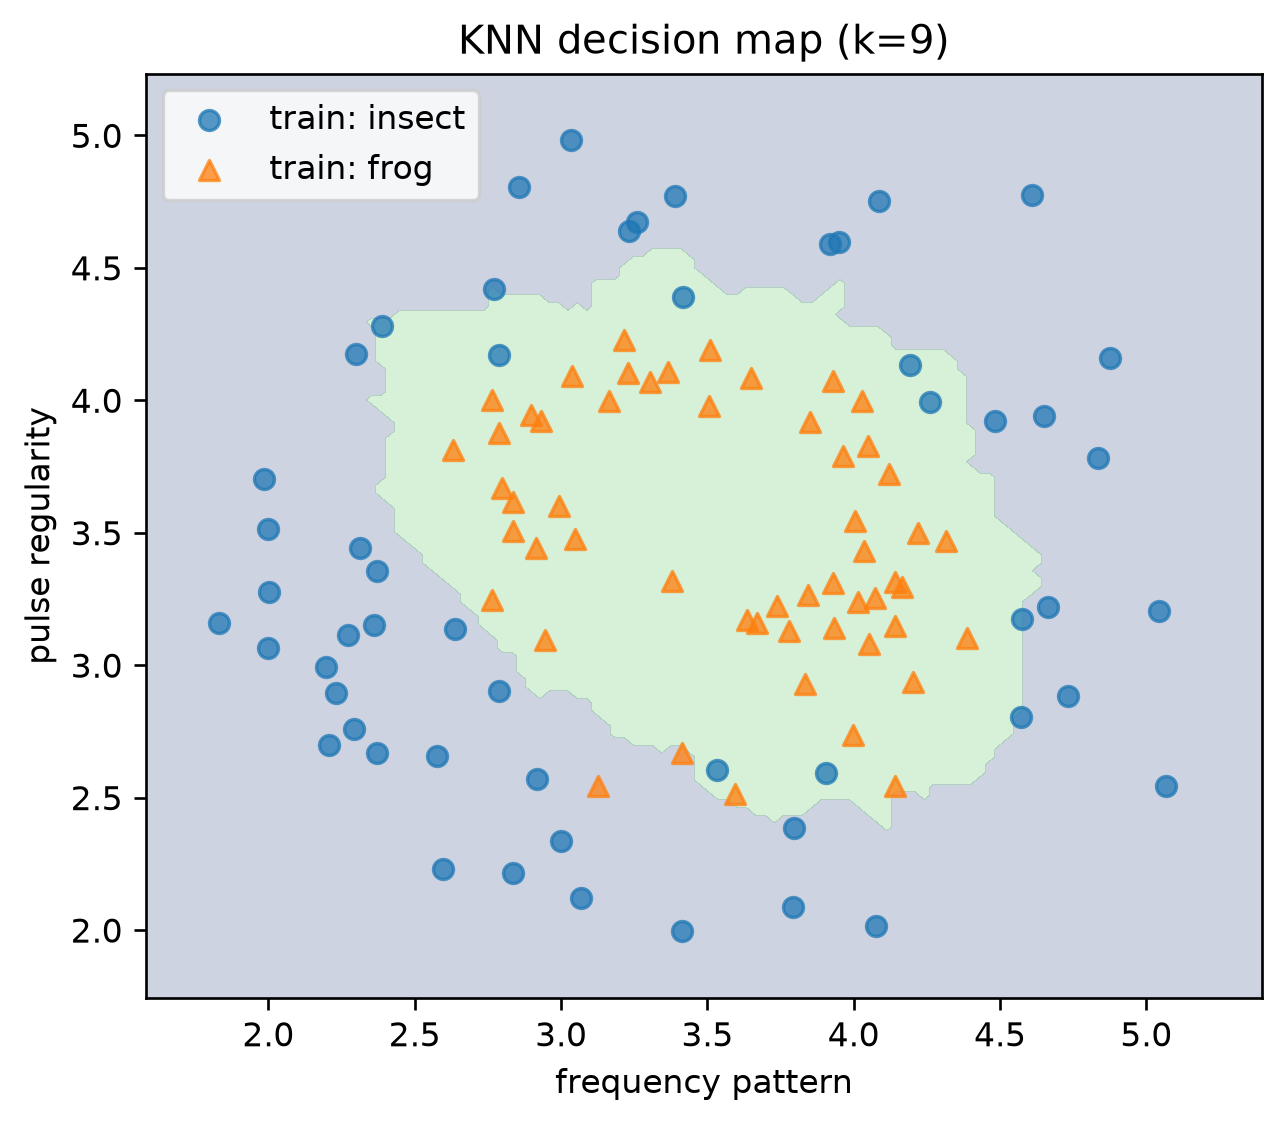

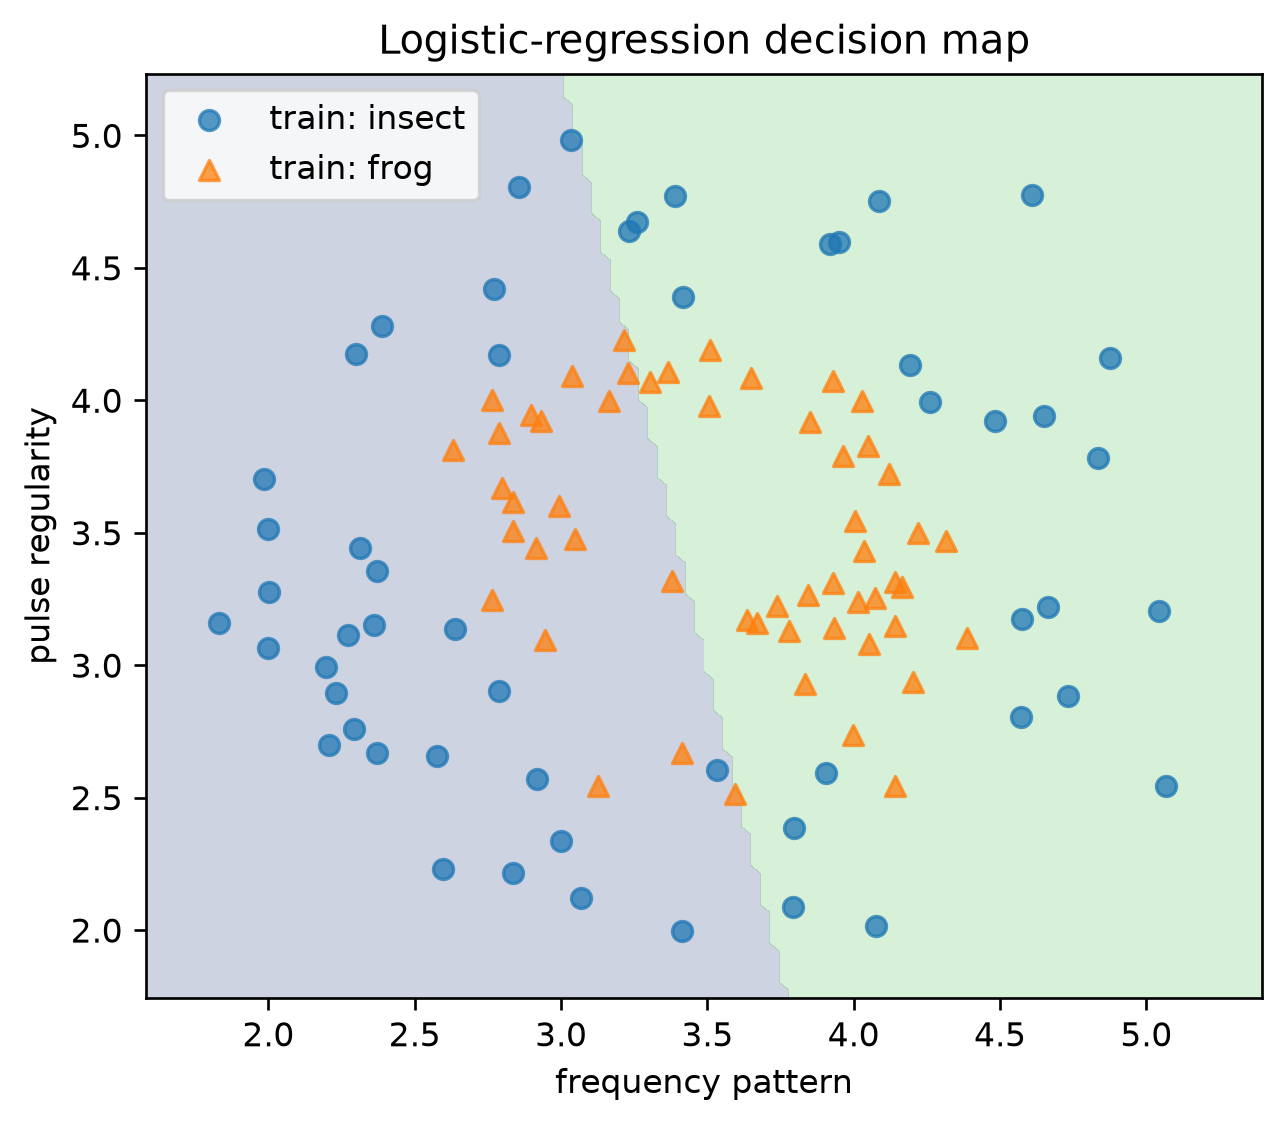

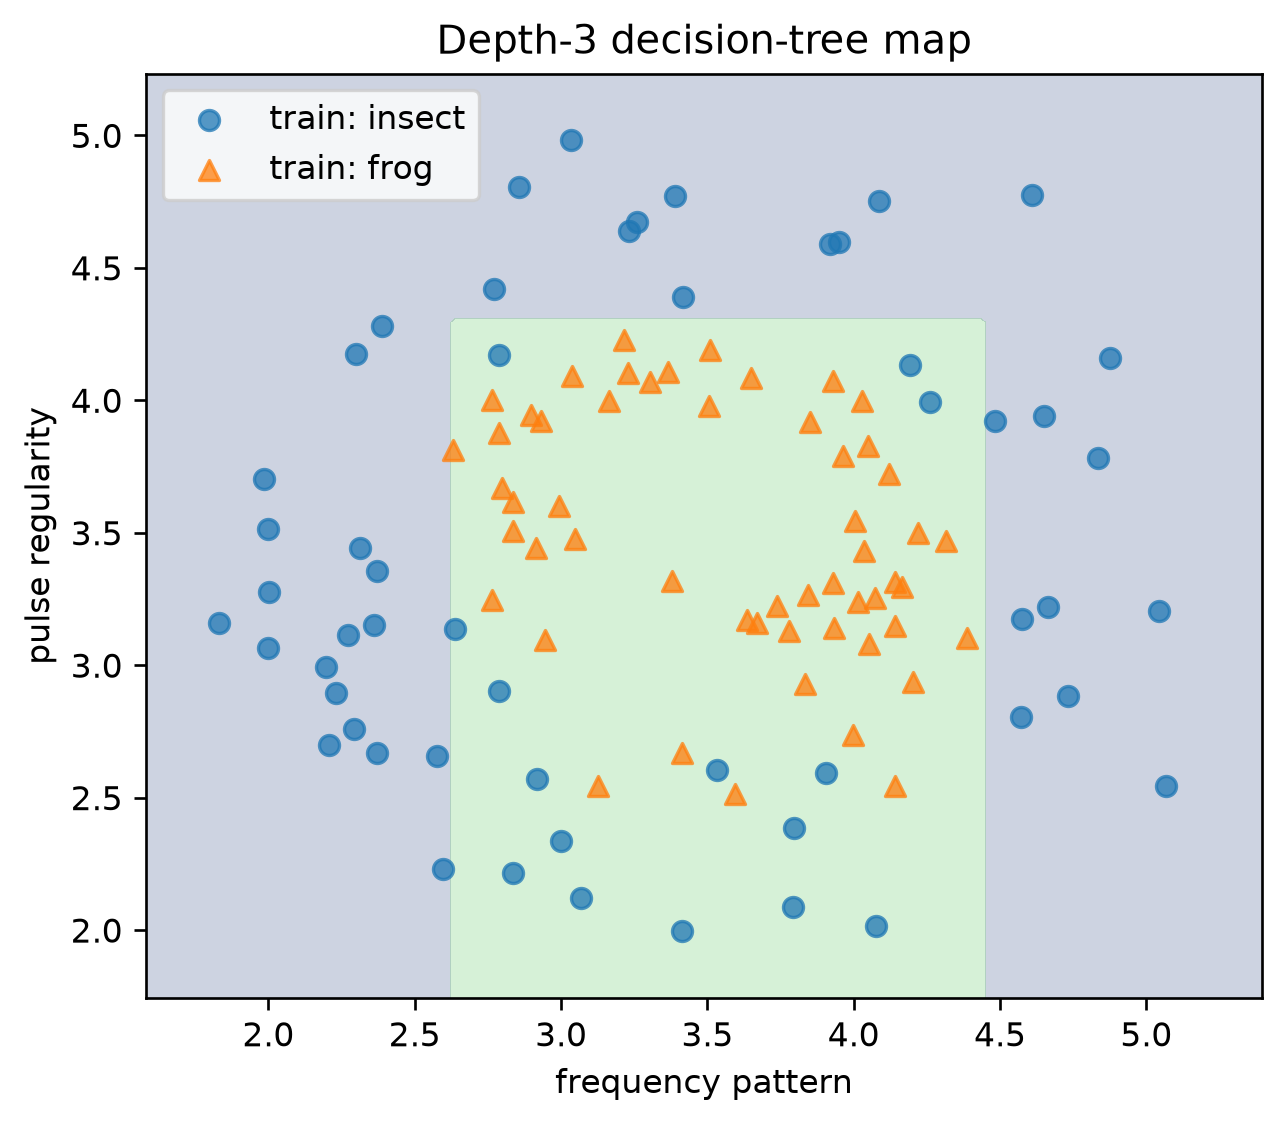

In [105]:
def plot_decision_boundary(title, predict_fn):
    x1 = np.linspace(X_all[:, 0].min() - 0.25, X_all[:, 0].max() + 0.25, 120)
    x2 = np.linspace(X_all[:, 1].min() - 0.25, X_all[:, 1].max() + 0.25, 120)
    grid_x1, grid_x2 = np.meshgrid(x1, x2)
    grid = np.column_stack([grid_x1.ravel(), grid_x2.ravel()])
    grid_labels = predict_fn(grid).reshape(grid_x1.shape)

    plt.figure(figsize=(6.0, 5.0))
    plt.contourf(grid_x1, grid_x2, grid_labels, levels=[-0.5, 0.5, 1.5], alpha=0.25)
    for label, marker in [(0, "o"), (1, "^")]:
        mask = y_train == label
        plt.scatter(
            X_train[mask, 0], X_train[mask, 1], marker=marker,
            label=f"train: {class_names[label]}", alpha=0.75
        )
    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])
    plt.title(title)
    plt.legend()
    plt.show()


plot_decision_boundary(f"KNN decision map (k={best_k})", predictors["KNN"])
plot_decision_boundary("Logistic-regression decision map", predictors["Logistic regression"])
plot_decision_boundary("Depth-3 decision-tree map", predictors["Decision tree"])

## Part 6 — Interpret the workflow (5 points, ~3 minutes)

### YOUR RESPONSE

In **3–5 sentences**, answer both questions:

1. Which model did validation select, and what kind of decision boundary does that model construct?
2. Why should you not keep changing the model after seeing its test accuracy?

**Response:** 

1. The validation selected KNN... hooray! The decision boundary it constructed was super complex and pretty accurately marked the distinction between the two classifications (it made a big circle in the middle for the frogs and everything else was the insects).

2. You should not keep changing the model after seeing its test accuracy because that would be fitting the model to the test data, which completely destroys the purpose and integrity of having the test data in the first place. The test set is meant to provide an unbiased estimate of how well the final model generalizes to unseen data. Thus, the reported test accuracy is no longer a reliable measure of generalization.

## Submission checklist

- [ ] Every required public check passes.
- [ ] `best_k` was chosen from validation scores, not test scores.
- [ ] The test set is evaluated only after the workflow is selected.
- [ ] No required function name or signature changed.
- [ ] The notebook runs after **Restart → Run all**.
- [ ] The response is 3–5 sentences.

### AI / collaboration disclosure — not graded

State `None`, or briefly describe substantive assistance. Ordinary syntax lookup does not need to be listed.

**Disclosure:** None / replace with a brief note.

# Optional Deep Dive — Change the representation, change the model

**Estimated time: 45–90+ minutes · Up to 10 bonus points**

The required assignment compares three model families. The optional work asks deeper questions:

- Can KNN compute all distances at once?
- Can a “linear” classifier draw a curved boundary after feature engineering?
- Can two models have similar accuracy but different probability quality?

In [ ]:
# Leave a flag False to skip that optional section during Restart → Run all.
RUN_BONUS_A = False
RUN_BONUS_B = False
RUN_BONUS_C = False

## Bonus A — Vectorize all KNN distances (3 points)

For `m` query rows and `n` training rows, broadcasting can create an `(m, n, d)` difference tensor and reduce it to an `(m, n)` distance matrix. This is the same math as before, but it moves the outer Python loop into NumPy.

In [ ]:
def pairwise_distances(X_query, X_train):
    """Return all query-to-training Euclidean distances with shape (m, n)."""
    X_query = np.asarray(X_query, dtype=float)
    X_train = np.asarray(X_train, dtype=float)

    # Broadcasting creates shape (m, n, d): every query minus every train row.
    differences = X_query[:, None, :] - X_train[None, :, :]

    # TODO: reduce over the feature axis to produce shape (m, n).
    raise NotImplementedError("Complete pairwise_distances")

In [ ]:
if RUN_BONUS_A:
    demo = pairwise_distances(X_val[:4], X_train[:7])
    assert demo.shape == (4, 7)
    assert np.allclose(demo[0], euclidean_distances(X_train[:7], X_val[0]))
    print("✓ Bonus A public check passed")

## Bonus B — Make a curved logistic boundary with quadratic features (4 points)

Logistic regression is linear **in its input features**. If we map

$$
(x_1,x_2)\mapsto(x_1,x_2,x_1^2,x_1x_2,x_2^2),
$$

a linear score in the expanded feature space becomes a curved boundary in the original two-dimensional plot. This directly connects polynomial regression to classification.

In [ ]:
def quadratic_features(X):
    """Map two features to [x1, x2, x1^2, x1*x2, x2^2]."""
    X = np.asarray(X, dtype=float)
    x1, x2 = X[:, 0], X[:, 1]

    # TODO: return a five-column feature matrix in the documented order.
    raise NotImplementedError("Complete quadratic_features")

In [ ]:
if RUN_BONUS_B:
    sample = np.array([[2.0, 3.0], [-1.0, 4.0]])
    expected = np.array([[2.0, 3.0, 4.0, 6.0, 9.0],
                         [-1.0, 4.0, 1.0, -4.0, 16.0]])
    assert np.allclose(quadratic_features(sample), expected)
    print("✓ Bonus B public check passed")

In [ ]:
if RUN_BONUS_B:
    Q_train = quadratic_features(X_train)
    Q_val = quadratic_features(X_val)

    # Scale using training statistics only.
    q_mean = Q_train.mean(axis=0)
    q_std = Q_train.std(axis=0)
    q_std[q_std == 0] = 1.0
    Q_train_scaled = (Q_train - q_mean) / q_std
    Q_val_scaled = (Q_val - q_mean) / q_std

    quad_w, quad_b, quad_history = fit_logistic_guided(
        Q_train_scaled,
        y_train,
        learning_rate=0.20,
        num_steps=10000,
        l2=0.0,
    )
    quad_val_probabilities = logistic_predict_proba(Q_val_scaled, quad_w, quad_b)
    quad_val_predictions = (quad_val_probabilities >= 0.5).astype(int)
    print("Quadratic-logistic validation accuracy:",
          accuracy_score(y_val, quad_val_predictions))

    def quadratic_logistic_predictor(X):
        Q = (quadratic_features(X) - q_mean) / q_std
        return logistic_predict(Q, quad_w, quad_b)

    plot_decision_boundary(
        "Quadratic-feature logistic decision map",
        quadratic_logistic_predictor,
    )

## Bonus C — Accuracy is not probability quality (3 points)

Binary negative log-likelihood rewards confident correct probabilities and strongly penalizes confident wrong ones:

$$
\mathrm{NLL}=-\frac{1}{n}\sum_i\left[y_i\log p_i+(1-y_i)\log(1-p_i)\right].
$$

Implement a numerically safe version.

In [ ]:
def binary_log_loss(y_true, probabilities):
    """Return mean binary negative log-likelihood."""
    y_true = np.asarray(y_true, dtype=float)
    probabilities = np.asarray(probabilities, dtype=float)
    if y_true.shape != probabilities.shape or y_true.size == 0:
        raise ValueError("inputs must be nonempty and have the same shape")

    # Keep log(0) out of the building.
    p = np.clip(probabilities, 1e-12, 1.0 - 1e-12)

    # TODO: implement mean binary NLL.
    raise NotImplementedError("Complete binary_log_loss")

In [ ]:
if RUN_BONUS_C:
    y_demo = np.array([0.0, 1.0])
    p_demo = np.array([0.25, 0.80])
    expected = -np.mean(y_demo * np.log(p_demo) + (1 - y_demo) * np.log(1 - p_demo))
    assert np.isclose(binary_log_loss(y_demo, p_demo), expected)
    print("✓ Bonus C public check passed")

In [ ]:
if RUN_BONUS_B and RUN_BONUS_C:
    plain_val_probabilities = logistic_predict_proba(X_val, logistic_w, logistic_b)
    print("Plain logistic validation NLL:",
          binary_log_loss(y_val, plain_val_probabilities))
    print("Quadratic logistic validation NLL:",
          binary_log_loss(y_val, quad_val_probabilities))

# Go further

Use these in roughly this order:

1. **Classification workflow:** [Google Machine Learning Crash Course — Classification](https://developers.google.com/machine-learning/crash-course/classification)
2. **K-nearest neighbors:** [scikit-learn user guide — Nearest Neighbors](https://scikit-learn.org/stable/modules/neighbors.html)
3. **Logistic regression and log loss:** [scikit-learn user guide — Logistic Regression](https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression)
4. **Decision trees and impurity:** [scikit-learn user guide — Decision Trees](https://scikit-learn.org/stable/modules/tree.html)
5. **Linear classifiers and decision boundaries:** [Stanford CS231n — Linear Classification](https://cs231n.github.io/linear-classify/)
6. **Broader supervised-learning perspective:** [*An Introduction to Statistical Learning*](https://www.statlearning.com/)

### A useful next question

The quadratic-feature model can draw a ring even though logistic regression is still linear in its expanded inputs. When is it better to engineer features, and when is it better to choose a model family that learns nonlinear structure directly?